In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Factorization Machines

Factorization machines (FM), proposed by @Rendle.2010, are a supervised algorithm that can be used for classification, regression, and ranking tasks. It quickly took notice and became a popular and impactful method for making predictions and recommendations. Particularly, it is a generalization of the linear regression model and the matrix factorization model. Moreover, it is reminiscent of support vector machines with a polynomial kernel. The strengths of factorization machines over the linear regression and matrix factorization are: (1) it can model $\chi$-way variable interactions, where $\chi$ is the number of polynomial order and is usually set to two. (2) A fast optimization algorithm associated with factorization machines can reduce the polynomial computation time to linear complexity, making it extremely efficient especially for high dimensional sparse inputs.  For these reasons, factorization machines are widely employed in modern advertisement and products recommendations. The technical details and implementations are described below.


## 2-Way Factorization Machines

Formally, let $x \in \mathbb{R}^d$ denote the feature vectors of one sample, and $y$ denote the corresponding label which can be real-valued label or class label such as binary class "click/non-click". The model for a factorization machine of degree two is defined as:

$$
\hat{y}(x) = \mathbf{w}_0 + \sum_{i=1}^d \mathbf{w}_i x_i + \sum_{i=1}^d\sum_{j=i+1}^d \langle\mathbf{v}_i, \mathbf{v}_j\rangle x_i x_j
$$

where $\mathbf{w}_0 \in \mathbb{R}$ is the global bias; $\mathbf{w} \in \mathbb{R}^d$ is the vector of linear weights, whose $i^\textrm{th}$ entry $\mathbf{w}_i$ is the weight of the $i^\textrm{th}$ variable; $\mathbf{V} \in \mathbb{R}^{d\times k}$ represents the feature embeddings; $\mathbf{v}_i$ represents the $i^\textrm{th}$ row of $\mathbf{V}$; $k$ is the dimensionality of latent factors; $\langle\cdot, \cdot \rangle$ is the dot product of two vectors.  $\langle \mathbf{v}_i, \mathbf{v}_j \rangle$ model the interaction between the $i^\textrm{th}$ and $j^\textrm{th}$ feature. Some feature interactions can be easily understood so they can be designed by experts. However, most other feature interactions are hidden in data and difficult to identify. So modeling feature interactions automatically can greatly reduce the efforts in feature engineering. It is obvious that the first two terms correspond to the linear regression model and the last term is an extension of the matrix factorization model. If the feature $i$ represents an item and the feature $j$ represents a user, the third term is exactly the dot product between user and item embeddings. It is worth noting that FM can also generalize to higher orders (degree > 2). Nevertheless, the numerical stability might weaken the generalization.


## An Efficient Optimization Criterion

Optimizing the factorization machines in a  straight forward method leads to a complexity of $\mathcal{O}(kd^2)$ as all pairwise interactions require to be computed. To solve this inefficiency problem, we can reorganize the third term of FM which could greatly reduce the computation cost, leading to a linear time complexity ($\mathcal{O}(kd)$).  The reformulation of the pairwise interaction term is as follows:

$$
\begin{aligned}
&\sum_{i=1}^d \sum_{j=i+1}^d \langle\mathbf{v}_i, \mathbf{v}_j\rangle x_i x_j \\
 &= \frac{1}{2} \sum_{i=1}^d \sum_{j=1}^d\langle\mathbf{v}_i, \mathbf{v}_j\rangle x_i x_j - \frac{1}{2}\sum_{i=1}^d \langle\mathbf{v}_i, \mathbf{v}_i\rangle x_i x_i \\
 &= \frac{1}{2} \big (\sum_{i=1}^d \sum_{j=1}^d \sum_{l=1}^k\mathbf{v}_{i, l} \mathbf{v}_{j, l} x_i x_j - \sum_{i=1}^d \sum_{l=1}^k \mathbf{v}_{i, l} \mathbf{v}_{i, l} x_i x_i \big)\\
 &=  \frac{1}{2} \sum_{l=1}^k \big ((\sum_{i=1}^d \mathbf{v}_{i, l} x_i) (\sum_{j=1}^d \mathbf{v}_{j, l}x_j) - \sum_{i=1}^d \mathbf{v}_{i, l}^2 x_i^2 \big ) \\
 &= \frac{1}{2} \sum_{l=1}^k \big ((\sum_{i=1}^d \mathbf{v}_{i, l} x_i)^2 - \sum_{i=1}^d \mathbf{v}_{i, l}^2 x_i^2 \big )
 \end{aligned}
$$

With this reformulation, the model complexity is decreased greatly. Moreover, for sparse features, only non-zero elements need to be computed so that the overall complexity is linear to the number of non-zero features.

To learn the FM model, we can use the MSE loss for regression task, the cross-entropy loss for classification tasks, and the BPR loss for ranking task. Standard optimizers such as stochastic gradient descent and Adam are viable for optimization.

In [1]:
from d2l import torch as d2l
import torch
from torch import nn
import os

## Model Implementation
The following code implement the factorization machines. It is clear to see that FM consists a linear regression block and an efficient feature interaction block. The model returns raw scores (logits); the sigmoid transformation is absorbed into the loss function (`SigmoidBinaryCrossEntropyLoss` / `BCEWithLogitsLoss`) for numerical stability.

In [2]:
class FM(nn.Module):
    def __init__(self, field_dims, num_factors):
        super().__init__()
        num_inputs = int(sum(field_dims))
        self.embedding = nn.Embedding(num_inputs, num_factors)
        self.fc = nn.Embedding(num_inputs, 1)
        self.linear_layer = nn.Linear(1, 1)

    def forward(self, x):
        square_of_sum = self.embedding(x).sum(dim=1) ** 2
        sum_of_square = (self.embedding(x) ** 2).sum(dim=1)
        x = self.linear_layer(self.fc(x).sum(dim=1)) \
            + 0.5 * (square_of_sum - sum_of_square).sum(dim=1, keepdim=True)
        return x

## Load the Advertising Dataset
We use the CTR data wrapper from the last section to load the online advertising dataset.

In [3]:
batch_size = 2048
data_dir = d2l.download_extract('ctr')
train_data = d2l.CTRDataset(os.path.join(data_dir, 'train.csv'))
test_data = d2l.CTRDataset(os.path.join(data_dir, 'test.csv'),
                           feat_mapper=train_data.feat_mapper,
                           defaults=train_data.defaults)
train_iter = torch.utils.data.DataLoader(
    train_data, shuffle=True, drop_last=True, batch_size=batch_size,
    num_workers=d2l.get_dataloader_workers())
test_iter = torch.utils.data.DataLoader(
    test_data, shuffle=False, drop_last=True, batch_size=batch_size,
    num_workers=d2l.get_dataloader_workers())

## Train the Model
Afterwards, we train the model. The learning rate is set to 0.02 and the embedding size is set to 20 by default. The `Adam` optimizer and the `SigmoidBinaryCrossEntropyLoss` loss are used for model training.

loss 0.004, train acc 1.000, test acc 0.929
332248.9 examples/sec on [device(type='cuda', index=0)]


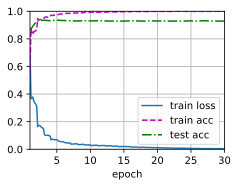

In [4]:
devices = d2l.try_all_gpus()
net = FM(train_data.field_dims, num_factors=20)

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
    if type(m) == nn.Embedding:
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights)
lr, num_epochs = 0.02, 30
optimizer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.BCEWithLogitsLoss(reduction='none')
d2l.train_ch13(net, train_iter, test_iter, loss, optimizer, num_epochs, devices)

## Summary

* FM is a general framework that can be applied on a variety of tasks such as regression, classification, and ranking.
* Feature interaction/crossing is important for prediction tasks and the 2-way interaction can be efficiently modeled with FM.

## Exercises

* Can you test FM on other dataset such as Avazu, MovieLens, and Criteo datasets?
* Vary the embedding size to check its impact on performance, can you observe a similar pattern as that of matrix factorization?

[Discussions](https://d2l.discourse.group/t/406)